# Análise Exploratória de Dados (EDA) — VibeBridge
Análise de atributos de áudio, popularidade e distribuição de gêneros musicais do Spotify.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset tratado
df = pd.read_csv('dataset_tratado.csv')

# Remover coluna de índice redundante, se existir
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [11]:
# 2. Resumo Estrutural e Estatístico
print("Dimensões do dataset:", df.shape)

print("\n--- Músicas Mais Populares ---")
display(df[['track_name', 'artists', 'track_genre', 'popularity']].sort_values(by='popularity', ascending=False).head(5))

print("\n--- Estatísticas dos Atributos de Áudio ---")
display(df[['popularity', 'danceability', 'energy', 'loudness', 'valence', 'tempo']].describe().round(2))

Dimensões do dataset: (80583, 20)

--- Músicas Mais Populares ---


,track_name,artists,track_genre,popularity
16936,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
41074,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
16943,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
50895,La Bachata,Manuel Turizo,latin,98
50896,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97



--- Estatísticas dos Atributos de Áudio ---


,popularity,danceability,energy,loudness,valence,tempo
count,80583.00,80583.00,80583.00,80583.00,80583.00,80583.00
mean,34.75,0.56,0.64,-8.56,0.46,122.21
std,19.45,0.18,0.26,5.26,0.26,30.07
min,0.00,0.00,0.00,-49.53,0.00,0.00
25%,21.00,0.45,0.46,-10.41,0.24,99.59
50%,35.00,0.57,0.68,-7.25,0.45,122.05
75%,49.00,0.69,0.86,-5.14,0.68,140.15
max,100.00,0.98,1.00,4.53,1.00,243.37


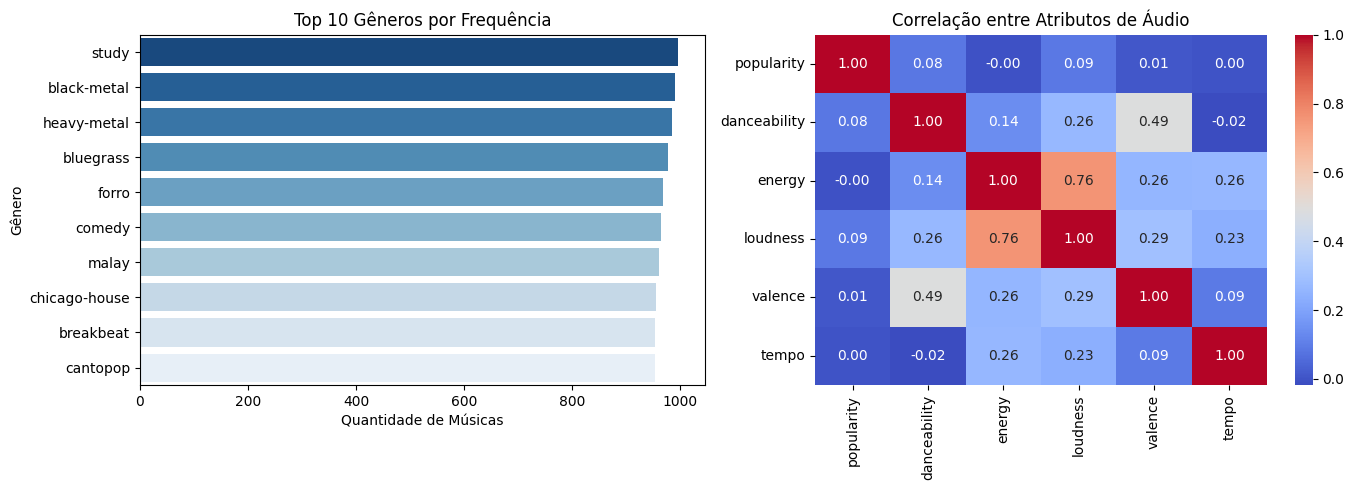

In [9]:
# 3. Visualização Gráfica das Distribuições e Correlações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 gêneros por frequência
top_genres = df['track_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], hue=top_genres.index, palette="Blues_r", legend=False)
axes[0].set_title('Top 10 Gêneros por Frequência')
axes[0].set_xlabel('Quantidade de Músicas')
axes[0].set_ylabel('Gênero')

# Matriz de Correlação dos atributos de áudio
features = ['popularity', 'danceability', 'energy', 'loudness', 'valence', 'tempo']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlação entre Atributos de Áudio')

plt.tight_layout()
plt.show()